<a href="https://colab.research.google.com/github/celinadavis25-cell/Machine-Learning/blob/main/Loan_approval_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loans = pd.read_csv("loan_approval.csv")
loans.head(10)

,Applicant_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Years_Employed,Existing_Loans,Property_Area,Loan_Approved
0,LN100487,Male,No,2.0,Graduate,No,37588.18,8795.55,6204.74,180,676.0,9.0,0,Semiurban,1
1,LN100824,Male,Yes,0.0,Graduate,No,25573.68,0.00,5855.69,360,609.0,3.6,0,Semiurban,1
2,LN100735,Female,No,2.0,Graduate,Yes,90057.91,29303.66,14043.51,180,742.0,3.9,0,Urban,1
3,LN100512,Female,No,0.0,Not Graduate,Yes,98440.57,0.00,12115.84,300,606.0,2.0,0,Rural,0
4,LN100203,NaN,Yes,0.0,Not Graduate,No,11534.51,0.00,NaN,360,667.0,18.9,0,Urban,1
5,LN100734,Male,Yes,3.0,Graduate,No,71755.73,0.00,10669.98,300,531.0,2.1,0,Semiurban,1
6,LN100316,Male,Yes,0.0,Graduate,No,46609.59,18055.15,15254.85,240,779.0,4.8,0,Urban,1
7,LN100162,Female,Yes,0.0,Graduate,No,47360.71,0.00,8019.28,180,683.0,0.9,0,Semiurban,0
8,LN100201,Male,Yes,0.0,Graduate,NaN,58186.52,0.00,13108.55,240,566.0,3.9,0,Rural,0
9,LN100022,Male,No,3.0,Graduate,No,35083.12,0.00,6848.01,360,620.0,1.1,0,Urban,1


In [131]:
loans.shape

(1020, 15)

In [132]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1020 non-null   object 
 1   Gender              989 non-null    object 
 2   Married             1020 non-null   object 
 3   Dependents          1000 non-null   float64
 4   Education           1020 non-null   object 
 5   Self_Employed       969 non-null    object 
 6   Applicant_Income    1020 non-null   float64
 7   Coapplicant_Income  1020 non-null   float64
 8   Loan_Amount         1000 non-null   float64
 9   Loan_Term_Months    1020 non-null   int64  
 10  Credit_Score        979 non-null    float64
 11  Years_Employed      989 non-null    float64
 12  Existing_Loans      1020 non-null   int64  
 13  Property_Area       1020 non-null   object 
 14  Loan_Approved       1020 non-null   int64  
dtypes: float64(6), int64(3), object(6)
memory usage: 119.7+

In [133]:
loans.isnull()

,Applicant_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Years_Employed,Existing_Loans,Property_Area,Loan_Approved
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1016,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1017,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1018,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [134]:
loans.isnull().sum()

,0
Applicant_ID,0
Gender,31
Married,0
Dependents,20
Education,0
Self_Employed,51
Applicant_Income,0
Coapplicant_Income,0
Loan_Amount,20
Loan_Term_Months,0


In [135]:
loans.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1015,False
1016,False
1017,False
1018,False


In [136]:
loans.duplicated().sum()

np.int64(20)

In [137]:
loans["Loan_Approved"].value_counts()

,count
Loan_Approved,
1,581
0,439


In [138]:
loans["Gender"].unique()

array(['Male', 'Female', nan, 'male', 'female'], dtype=object)

In [139]:
loans["Married"].unique()

array(['No', 'Yes', ' Yes ', ' No '], dtype=object)

In [140]:
loans["Education"].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [141]:
loans["Self_Employed"].unique()

array(['No', 'Yes', nan], dtype=object)

In [142]:
loans["Property_Area"].unique()

array(['Semiurban', 'Urban', 'Rural', 'URBAN', 'SEMIURBAN', 'RURAL'],
      dtype=object)

In [143]:
categorical_cols = ["Gender", "Married", "Education", "Self_Employed", "Property_Area"]

for col in categorical_cols:
  loans[col] = loans[col].astype(str).str.strip().str.title()
  loans[col] = loans[col].replace("Nan", np.nan)




In [144]:
loans["Gender"].unique()

array(['Male', 'Female', nan], dtype=object)

In [145]:
loans["Property_Area"].unique()

array(['Semiurban', 'Urban', 'Rural'], dtype=object)

In [146]:
numerical_cols = ["Credit_Score", "Loan_Amount", "Years_Employed","Dependents"]

for col in numerical_cols:
  loans[col] = loans[col].fillna(loans[col].median())


categorical_cols = ["Gender", "Self_Employed"]

for col in categorical_cols:
  loans[col] = loans[col].fillna(loans[col].mode()[0])

In [147]:
loans.isnull()

,Applicant_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Years_Employed,Existing_Loans,Property_Area,Loan_Approved
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1016,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1017,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1018,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [148]:
loans.isnull().sum()

,0
Applicant_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
Applicant_Income,0
Coapplicant_Income,0
Loan_Amount,0
Loan_Term_Months,0


In [149]:
print("Rows before removing duplicates:", len(loans))

loans = loans.drop_duplicates()

print("Rows after removung duplicates:", len(loans))

Rows before removing duplicates: 1020
Rows after removung duplicates: 1000


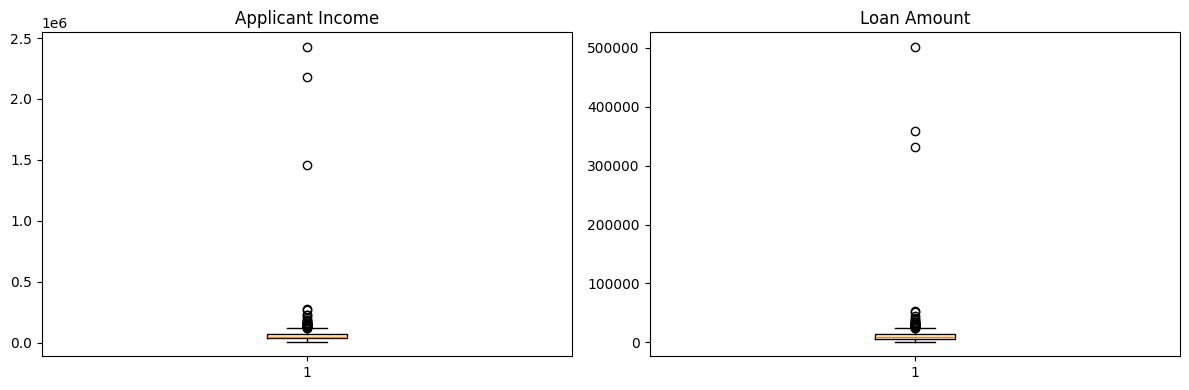

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(loans["Applicant_Income"])
axes[0].set_title("Applicant Income")

axes[1].boxplot(loans["Loan_Amount"])
axes[1].set_title("Loan Amount")

plt.tight_layout()
plt.show()

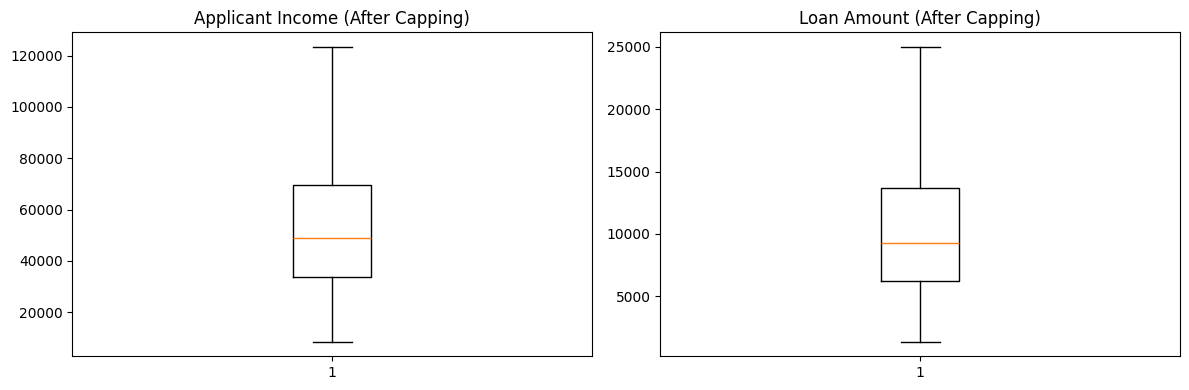

In [151]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

for col in ["Applicant_Income", "Coapplicant_Income", "Loan_Amount"]:
    loans = cap_outliers_iqr(loans, col)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(loans["Applicant_Income"])
axes[0].set_title("Applicant Income (After Capping)")
axes[1].boxplot(loans["Loan_Amount"])
axes[1].set_title("Loan Amount (After Capping)")
plt.tight_layout()
plt.show()

In [152]:
loans.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Years_Employed,Existing_Loans,Loan_Approved
count,1000.0000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.9650,54197.656826,9142.69527,10495.243377,270.240000,650.312000,4.973200,0.503000,0.572000
std,1.0143,27482.495741,12249.26908,5836.324478,79.002429,75.828086,5.125604,0.674126,0.495036
min,0.0000,8542.530000,0.00000,1379.910000,120.000000,448.000000,0.000000,0.000000,0.000000
25%,0.0000,33729.485000,0.00000,6196.100000,225.000000,601.000000,1.400000,0.000000,0.000000
50%,1.0000,48786.775000,0.00000,9266.695000,300.000000,651.000000,3.300000,0.000000,1.000000
75%,2.0000,69561.662500,16276.90000,13709.315000,360.000000,700.000000,6.825000,1.000000,1.000000
max,3.0000,123309.928750,40692.25000,24979.137500,360.000000,850.000000,33.800000,2.000000,1.000000


In [153]:
loans.to_csv("loan_approval_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [154]:
from google.colab import files

files.download("loan_approval_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [155]:
loans = pd.read_csv("loan_approval_cleaned.csv")

loans.head()

,Applicant_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Years_Employed,Existing_Loans,Property_Area,Loan_Approved
0,LN100487,Male,No,2.0,Graduate,No,37588.18,8795.55,6204.740,180,676.0,9.0,0,Semiurban,1
1,LN100824,Male,Yes,0.0,Graduate,No,25573.68,0.00,5855.690,360,609.0,3.6,0,Semiurban,1
2,LN100735,Female,No,2.0,Graduate,Yes,90057.91,29303.66,14043.510,180,742.0,3.9,0,Urban,1
3,LN100512,Female,No,0.0,Not Graduate,Yes,98440.57,0.00,12115.840,300,606.0,2.0,0,Rural,0
4,LN100203,Male,Yes,0.0,Not Graduate,No,11534.51,0.00,9266.695,360,667.0,18.9,0,Urban,1


In [156]:
loans.isnull().sum()

,0
Applicant_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
Applicant_Income,0
Coapplicant_Income,0
Loan_Amount,0
Loan_Term_Months,0


In [157]:
loans.duplicated().sum()

np.int64(0)

In [158]:
categorical_features = ["Gender", "Married", "Education", "Self_Employed", "Property_Area"]

loans_encoded = pd.get_dummies(loans, columns=categorical_features, dtype=int)

loans_encoded.head(10)

,Applicant_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Years_Employed,Existing_Loans,Loan_Approved,...,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LN100487,2.0,37588.18,8795.55,6204.740,180,676.0,9.0,0,1,...,1,1,0,1,0,1,0,0,1,0
1,LN100824,0.0,25573.68,0.00,5855.690,360,609.0,3.6,0,1,...,1,0,1,1,0,1,0,0,1,0
2,LN100735,2.0,90057.91,29303.66,14043.510,180,742.0,3.9,0,1,...,0,1,0,1,0,0,1,0,0,1
3,LN100512,0.0,98440.57,0.00,12115.840,300,606.0,2.0,0,0,...,0,1,0,0,1,0,1,1,0,0
4,LN100203,0.0,11534.51,0.00,9266.695,360,667.0,18.9,0,1,...,1,0,1,0,1,1,0,0,0,1
5,LN100734,3.0,71755.73,0.00,10669.980,300,531.0,2.1,0,1,...,1,0,1,1,0,1,0,0,1,0
6,LN100316,0.0,46609.59,18055.15,15254.850,240,779.0,4.8,0,1,...,1,0,1,1,0,1,0,0,0,1
7,LN100162,0.0,47360.71,0.00,8019.280,180,683.0,0.9,0,0,...,0,0,1,1,0,1,0,0,1,0
8,LN100201,0.0,58186.52,0.00,13108.550,240,566.0,3.9,0,0,...,1,0,1,1,0,1,0,1,0,0
9,LN100022,3.0,35083.12,0.00,6848.010,360,620.0,1.1,0,1,...,1,1,0,1,0,1,0,0,0,1


In [159]:
feature_columns = [c for c in loans_encoded.columns if c not in ["Applicant_ID", "Loan_Approved"]]

X = loans_encoded[feature_columns]
y = loans_encoded["Loan_Approved"]

print("Number of featured:", X.shape[1])
X.head(10)

Number of featured: 19


,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Years_Employed,Existing_Loans,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,2.0,37588.18,8795.55,6204.740,180,676.0,9.0,0,0,1,1,0,1,0,1,0,0,1,0
1,0.0,25573.68,0.00,5855.690,360,609.0,3.6,0,0,1,0,1,1,0,1,0,0,1,0
2,2.0,90057.91,29303.66,14043.510,180,742.0,3.9,0,1,0,1,0,1,0,0,1,0,0,1
3,0.0,98440.57,0.00,12115.840,300,606.0,2.0,0,1,0,1,0,0,1,0,1,1,0,0
4,0.0,11534.51,0.00,9266.695,360,667.0,18.9,0,0,1,0,1,0,1,1,0,0,0,1
5,3.0,71755.73,0.00,10669.980,300,531.0,2.1,0,0,1,0,1,1,0,1,0,0,1,0
6,0.0,46609.59,18055.15,15254.850,240,779.0,4.8,0,0,1,0,1,1,0,1,0,0,0,1
7,0.0,47360.71,0.00,8019.280,180,683.0,0.9,0,1,0,0,1,1,0,1,0,0,1,0
8,0.0,58186.52,0.00,13108.550,240,566.0,3.9,0,0,1,0,1,1,0,1,0,1,0,0
9,3.0,35083.12,0.00,6848.010,360,620.0,1.1,0,0,1,1,0,1,0,1,0,0,0,1


In [160]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])

Training samples: 800
Testing samples: 200


In [161]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation= "relu"),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

In [162]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [163]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

print("Training complete.")

Training complete.


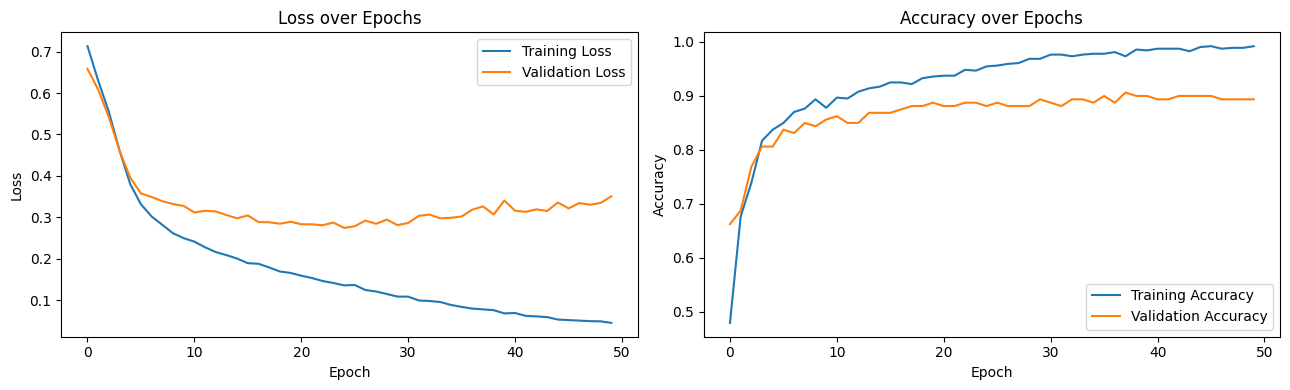

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"], label="Training Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Training Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [165]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.5272
Test Accuracy: 0.825


In [166]:
probabilities = model.predict(X_test_scaled, verbose=0)
predictions = (probabilities > 0.5).astype(int).flatten()

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions,
    "Probability": probabilities.flatten().round(3)
})

comparison.head(10)

,Actual,Predicted,Probability
0,0,0,0.237
1,0,1,0.811
2,1,1,1.000
3,1,1,1.000
4,0,0,0.026
5,0,0,0.012
6,1,1,0.978
7,0,0,0.000
8,0,1,0.881
9,1,1,0.653


In [167]:
cm = confusion_matrix(y_test, predictions)
cm

array([[ 62,  24],
       [ 11, 103]])

In [168]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.72      0.78        86
           1       0.81      0.90      0.85       114

    accuracy                           0.82       200
   macro avg       0.83      0.81      0.82       200
weighted avg       0.83      0.82      0.82       200



In [169]:
new_applicant = pd.DataFrame([{
    "Dependents": 1,
    "Applicant_Income": 85000,
    "Coapplicant_Income": 20000,
    "Loan_Amount": 15000,
    "Loan_Term_Months": 240,
    "Credit_Score": 710,
    "Years_Employed": 6.5,
    "Existing_Loans": 0,
    "Gender_Female": 0, "Gender_Male": 1,
    "Married_No": 0, "Married_Yes": 1,
    "Education_Graduate": 1, "Education_Not Graduate": 0,
    "Self_Employed_No": 1, "Self_Employed_Yes": 0,
    "Property_Area_Rural": 0, "Property_Area_Semiurban": 1, "Property_Area_Urban": 0,
}])

# Make sure the column order matches what the model was trained on
new_applicant = new_applicant[feature_columns]

new_applicant_scaled = scaler.transform(new_applicant)
probability = model.predict(new_applicant_scaled, verbose=0)[0][0]
decision = "Approved" if probability > 0.5 else "Rejected"

print(f"Predicted probability of approval: {probability:.2f}")
print(f"Decision: {decision}")

Predicted probability of approval: 1.00
Decision: Approved


In [170]:
print(f"Predicted probability of approval: {probability:.3f}")

Predicted probability of approval: 1.000
